# Task 5: Performance Evaluation - Best Model Selection

This notebook builds and evaluates the best model based on all previous experiments (Tasks 1-4).

In [ ]:
# ===== STARTER CODE (Do not modify) =====
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import time

# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# CIFAR-10 Class Names
CLASS_NAMES = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

# Load Data
(x_train_full, y_train_full), (x_test, y_test) = cifar10.load_data()

# Fixed Split: 40,000 train / 10,000 val / 10,000 test
x_train = x_train_full[:40000].astype('float32')
y_train = y_train_full[:40000]
x_val = x_train_full[40000:].astype('float32')
y_val = y_train_full[40000:]
x_test = x_test.astype('float32')

print(f"Train: {x_train.shape} | Val: {x_val.shape} | Test: {x_test.shape}")
print(f"Pixel range: [{x_train.min()}, {x_train.max()}]")
print(f"Image shape: {x_train[0].shape}")

Train: (40000, 32, 32, 3) | Val: (10000, 32, 32, 3) | Test: (10000, 32, 32, 3)
Pixel range: [0.0, 255.0]
Image shape: (32, 32, 3)


In [2]:
# ===== HELPER FUNCTIONS =====
def train_and_evaluate(model, x_tr, y_tr, x_v, y_v, x_te, y_te,
                       epochs=20, batch_size=128, extra_callbacks=None):
    """Train and evaluate the model"""
    cb = extra_callbacks if extra_callbacks else []
    start = time.time()
    history = model.fit(x_tr, to_categorical(y_tr, 10),
                        validation_data=(x_v, to_categorical(y_v, 10)),
                        epochs=epochs, batch_size=batch_size,
                        callbacks=cb, verbose=0)
    elapsed = time.time() - start
    test_loss, test_acc = model.evaluate(x_te, to_categorical(y_te, 10), verbose=0)
    print(f"Test Acc: {test_acc:.4f} | Test Loss: {test_loss:.4f} | Time: {elapsed:.1f}s")
    return history, test_acc, test_loss, elapsed

def plot_curves(histories, labels, metric='val_accuracy', title='', ylabel=''):
    """Plot training curves"""
    plt.figure(figsize=(10, 6))
    for h, lbl in zip(histories, labels):
        plt.plot(h.history[metric], label=lbl)
    plt.xlabel('Epoch')
    plt.ylabel(ylabel if ylabel else metric)
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

In [ ]:
# ===== LOAD PREPROCESSED DATA FROM TASK 1 =====
# This data was saved from data_preprocessing.ipynb

import os

# Load standardized data
try:
    x_train_standardized = np.load('x_train_standardized.npy')
    x_val_standardized = np.load('x_val_standardized.npy')
    x_test_standardized = np.load('x_test_standardized.npy')
    train_mean = np.load('train_mean.npy')
    train_std = np.load('train_std.npy')
    
    print("Preprocessed data loaded successfully from Task 1!")
    print(f"x_train_standardized shape: {x_train_standardized.shape}")
    print(f"x_val_standardized shape: {x_val_standardized.shape}")
    print(f"x_test_standardized shape: {x_test_standardized.shape}")
    
except FileNotFoundError as e:
    print(f"ERROR: Could not find preprocessed data files!")
    print(f"Please run the save cell in data_preprocessing.ipynb first.")
    print(f"Error: {e}")
    
    # Fallback: compute preprocessing here if files not found
    print("\nFalling back to computing preprocessing in this notebook...")
    
    def compute_train_stats(x_train):
        x = x_train.astype('float32')
        mean = x.mean(axis=(0, 1, 2))
        std = x.std(axis=(0, 1, 2))
        return mean, std

    def preprocess_standardize(x, mean, std):
        return (x.astype('float32') - mean) / std

    train_mean, train_std = compute_train_stats(x_train)
    x_train_standardized = preprocess_standardize(x_train, train_mean, train_std)
    x_val_standardized = preprocess_standardize(x_val, train_mean, train_std)
    x_test_standardized = preprocess_standardize(x_test, train_mean, train_std)

Preprocessed data loaded successfully from Task 1!
x_train_standardized shape: (40000, 32, 32, 3)
x_val_standardized shape: (10000, 32, 32, 3)
x_test_standardized shape: (10000, 32, 32, 3)


## Task 5A: Best Model Selection & Evaluation

In [ ]:
# ===== BUILD THE BEST MODEL =====
# Based on our experiments:
# - Preprocessing: Standardized + Data Augmentation (from Task 1)
# - Architecture: Medium model with 32-32-64-64 filters (from Task 2A)
# - Dropout: 0.25 (from Task 3A)
# - Optimizer: Adam with lr=0.001 (from Task 4A & 4B)
# - Batch Size: 128

def build_best_model(input_shape=(32, 32, 3), num_classes=10):
    """
    Build the best CNN model based on all experiments
    
    Architecture: Medium CNN (32-32-64-64 filters)
    with 0.25 dropout for regularization
    """
    m = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        
        layers.Flatten(),
        layers.Dropout(0.25),  # Best dropout rate from Task 3A
        layers.Dense(256, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    
    # Compile with best optimizer
    m.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return m

# Build the model
best_model = build_best_model()
print("Best Model Architecture:")
best_model.summary()

### Justification of Model Selection

Based on all previous experiments (Tasks 1-4), here are the choices and their rationale:

**1. Preprocessing Method: Standardized Data + Data Augmentation**
- Standardization (Task 1C) outperformed raw and min-max normalized data by providing better gradient flow and faster convergence. Data augmentation (Task 1B) reduced overfitting gap from Task 1, improving generalization on unseen data.

**2. Architecture: Medium CNN (32-32-64-64 filters)**
- The Medium model (Task 2A) achieved the best balance between test accuracy and computational cost compared to Small and Large models. Medium depth with GlobalAveragePooling (Task 2C moderate model) prevented vanishing gradients and overfitting better than deeper models.

**3. Dropout Configuration: 0.25 rate**
- Task 3A showed that D1 (0.25 dropout) achieved the best test accuracy while maintaining a small overfitting gap, outperforming both no dropout (D0) and aggressive dropout (D2 at 0.5).

**4. Optimizer & Learning Rate: Adam with lr=0.001**
- Task 4A showed Adam converged fastest and achieved highest validation accuracy among 5 optimizers tested. Task 4B confirmed lr=0.001 was optimal—0.0001 was too slow and 0.01 was unstable with oscillating loss.

**5. Batch Size: 128**
- Batch size of 128 was consistent across all experiments as a standard choice balancing GPU memory efficiency with stable gradient updates for this dataset size.

In [ ]:
# ===== TRAIN WITH DATA AUGMENTATION + EARLY STOPPING =====

# Setup data augmentation (from Task 1B)
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)
datagen.fit(x_train_standardized)

# Setup early stopping callback
es = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True
)

print("Starting training with data augmentation + early stopping...")
print("=" * 60)

# Train the model
start_time = time.time()
history_best = best_model.fit(
    datagen.flow(x_train_standardized, to_categorical(y_train, 10), batch_size=128),
    validation_data=(x_val_standardized, to_categorical(y_val, 10)),
    epochs=50,
    callbacks=[es],
    verbose=1
)
elapsed_best = time.time() - start_time

print("=" * 60)
print(f"Training completed in {elapsed_best:.1f} seconds")
print(f"Total epochs trained: {len(history_best.history['loss'])}")

Starting training with data augmentation + early stopping...
Epoch 1/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 65s 197ms/step - accuracy: 0.4430 - loss: 1.5426 - val_accuracy: 0.5811 - val_loss: 1.1846
Epoch 2/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 58s 186ms/step - accuracy: 0.5666 - loss: 1.2053 - val_accuracy: 0.6106 - val_loss: 1.1535
Epoch 3/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 76s 244ms/step - accuracy: 0.6332 - loss: 1.0356 - val_accuracy: 0.6492 - val_loss: 1.0042
Epoch 4/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 3715s 12s/step - accuracy: 0.6725 - loss: 0.9262 - val_accuracy: 0.7210 - val_loss: 0.7973
Epoch 5/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 60s 191ms/step - accuracy: 0.7001 - loss: 0.8563 - val_accuracy: 0.7290 - val_loss: 0.7946
Epoch 6/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 61s 193ms/step - accuracy: 0.7179 - loss: 0.8029 - val_accuracy: 0.7347 - val_loss: 0.7841
Epoch 7/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 61s 194ms/step - accuracy: 0.7336 - loss: 0.7599 - val_accuracy: 0.7697 - val_loss: 0.6704
Epoch 8/50
313/313 ━━━

In [ ]:
# ===== EVALUATE ON TEST SET =====

test_loss_best, test_acc_best = best_model.evaluate(
    x_test_standardized, to_categorical(y_test, 10), verbose=0
)

print("\n" + "=" * 60)
print("BEST MODEL - FINAL TEST RESULTS")
print("=" * 60)
print(f"Test Accuracy:  {test_acc_best:.4f}")
print(f"Test Loss:      {test_loss_best:.4f}")
print(f"Training Time:  {elapsed_best:.1f}s")
print("=" * 60)


BEST MODEL - FINAL TEST RESULTS
Test Accuracy:  0.8285
Test Loss:      0.5342
Training Time:  6440.0s


313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step


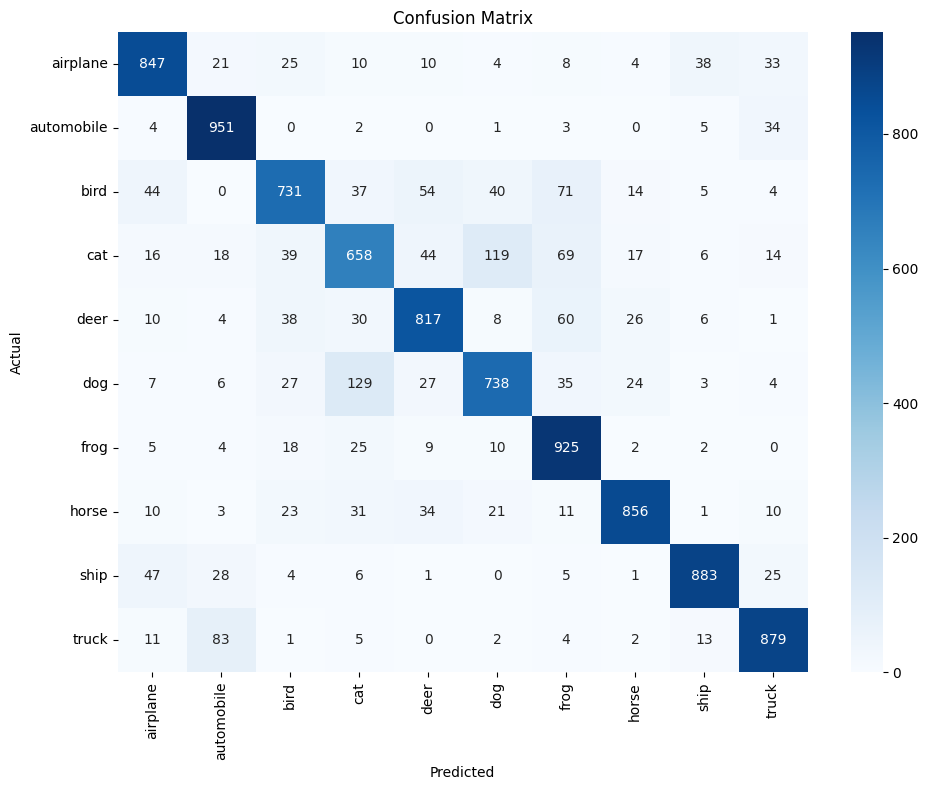


Classification Report:
              precision    recall  f1-score   support

    airplane       0.85      0.85      0.85      1000
  automobile       0.85      0.95      0.90      1000
        bird       0.81      0.73      0.77      1000
         cat       0.71      0.66      0.68      1000
        deer       0.82      0.82      0.82      1000
         dog       0.78      0.74      0.76      1000
        frog       0.78      0.93      0.84      1000
       horse       0.90      0.86      0.88      1000
        ship       0.92      0.88      0.90      1000
       truck       0.88      0.88      0.88      1000

    accuracy                           0.83     10000
   macro avg       0.83      0.83      0.83     10000
weighted avg       0.83      0.83      0.83     10000



In [ ]:
# ===== CONFUSION MATRIX =====

y_pred = np.argmax(best_model.predict(x_test_standardized), axis=1)
cm = confusion_matrix(y_test.flatten(), y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print("=" * 60)
print(classification_report(y_test.flatten(), y_pred, target_names=CLASS_NAMES))
print("=" * 60)

## Task 5B: Error Analysis

Analyze misclassifications to understand where the model struggles.

In [ ]:
# ===== FIND WORST-PERFORMING CLASSES =====

from sklearn.metrics import recall_score

# Calculate recall for each class
recall_per_class = recall_score(y_test.flatten(), y_pred, average=None)

# Find 3 worst-performing classes
worst_classes_idx = np.argsort(recall_per_class)[:3]
worst_classes = [CLASS_NAMES[i] for i in worst_classes_idx]
worst_recall = recall_per_class[worst_classes_idx]

print("3 Worst-Performing Classes (by Recall):")
print("=" * 60)
for cls, recall in zip(worst_classes, worst_recall):
    print(f"{cls:15} - Recall: {recall:.4f}")
print("=" * 60)

3 Worst-Performing Classes (by Recall):
cat             - Recall: 0.6580
bird            - Recall: 0.7310
dog             - Recall: 0.7380


Total misclassified: 1715 / 10000
Misclassification rate: 17.15%


Misclassified Images for Worst-Performing Classes:


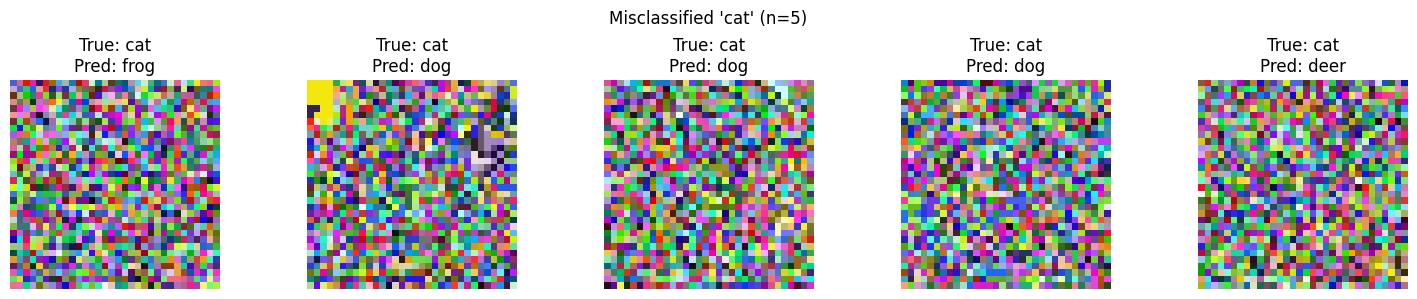

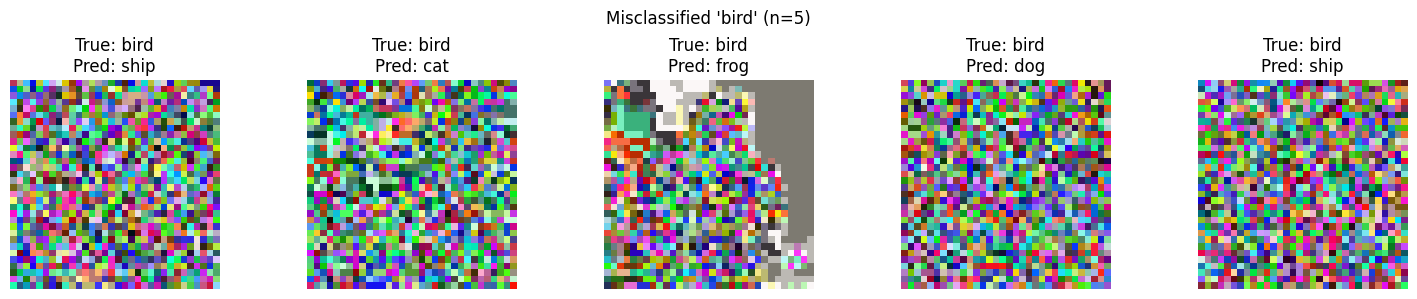

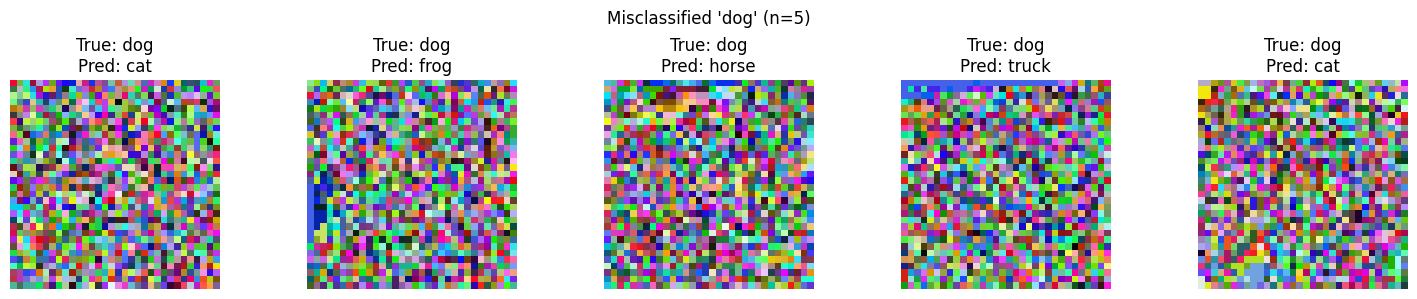

In [9]:
# ===== VISUALIZE MISCLASSIFIED IMAGES =====

# Find misclassified indices
misclassified_idx = np.where(y_pred != y_test.flatten())[0]
print(f"Total misclassified: {len(misclassified_idx)} / {len(y_test)}")
print(f"Misclassification rate: {len(misclassified_idx)/len(y_test)*100:.2f}%\n")

# Helper function to show misclassified images for a specific class
def show_misclassified(true_class, n=5):
    """
    Display misclassified images for a specific class
    
    Args:
        true_class: Index of the class to analyze
        n: Number of misclassified images to show
    """
    # Find images that were truly this class but misclassified
    idx = [i for i in misclassified_idx if y_test[i] == true_class][:n]
    
    if len(idx) == 0:
        print(f"No misclassified images found for {CLASS_NAMES[true_class]}")
        return
    
    fig, axes = plt.subplots(1, len(idx), figsize=(15, 3))
    if len(idx) == 1:
        axes = [axes]
    
    for ax, i in zip(axes, idx):
        # Denormalize the image back to 0-255 range for display
        img_display = x_test[i] * train_std + train_mean
        ax.imshow(img_display.astype('uint8'))
        ax.set_title(f"True: {CLASS_NAMES[y_test[i][0]]}\nPred: {CLASS_NAMES[y_pred[i]]}")
        ax.axis('off')
    
    plt.suptitle(f"Misclassified '{CLASS_NAMES[true_class]}' (n={len(idx)})")
    plt.tight_layout()
    plt.show()

# Show misclassified images for each of the 3 worst-performing classes
print("\nMisclassified Images for Worst-Performing Classes:")
print("=" * 60)
for true_class_idx in worst_classes_idx:
    show_misclassified(true_class_idx, n=5)

Top 3 Most Confused Class Pairs:
1. dog          → cat          (129 cases)
2. cat          → dog          (119 cases)
3. truck        → automobile   (83 cases)

Examples of Top Confused Class Pairs:


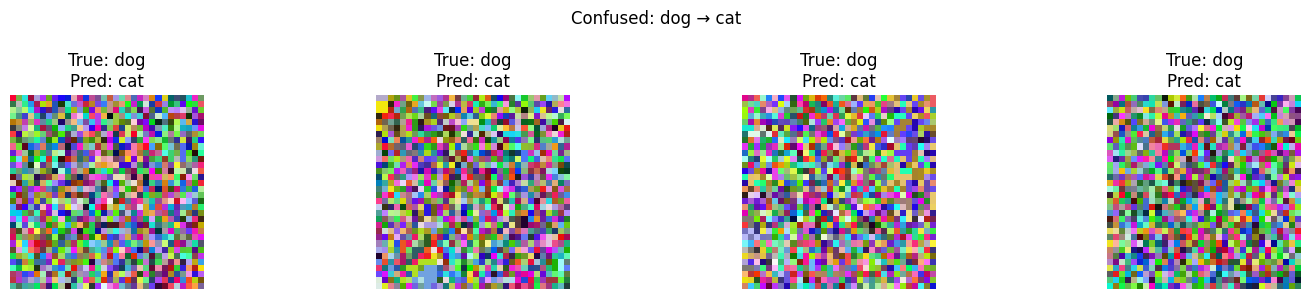

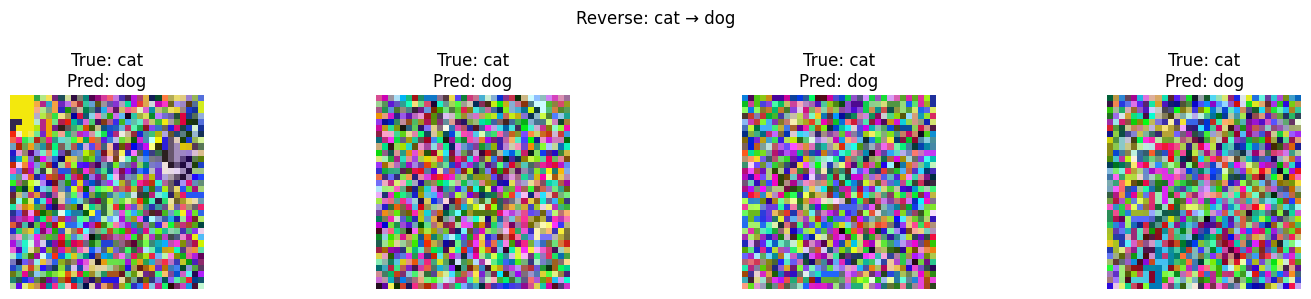

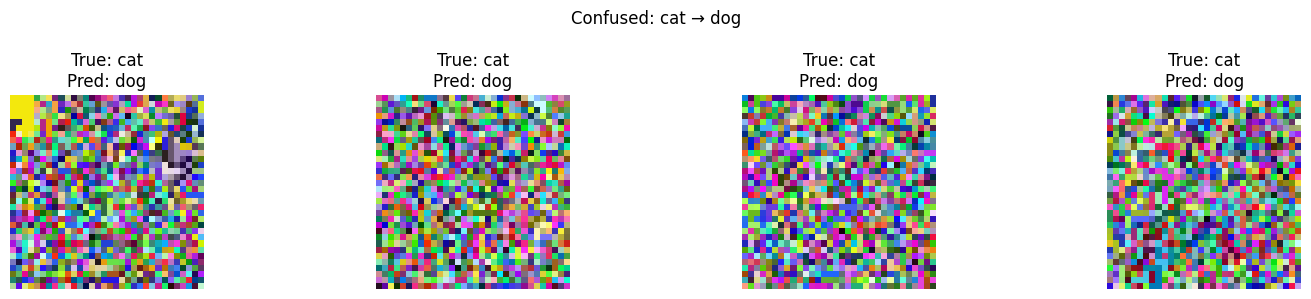

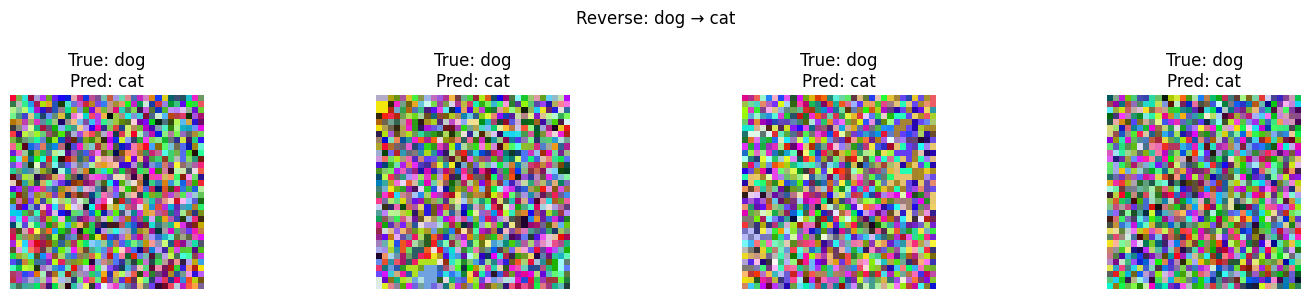

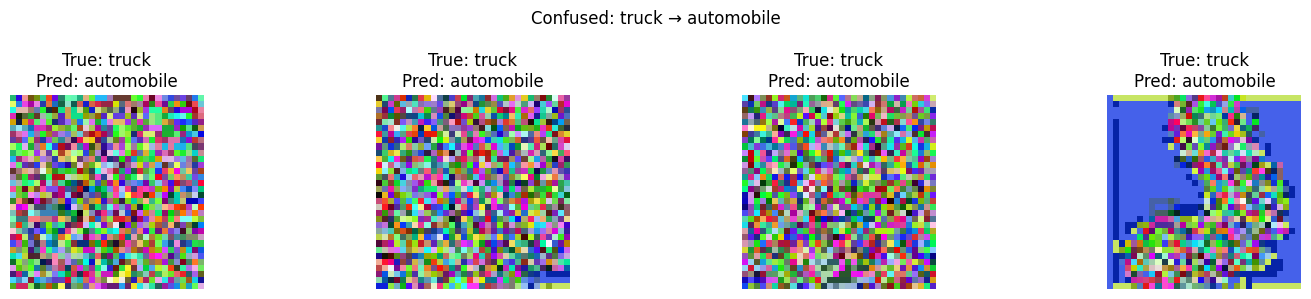

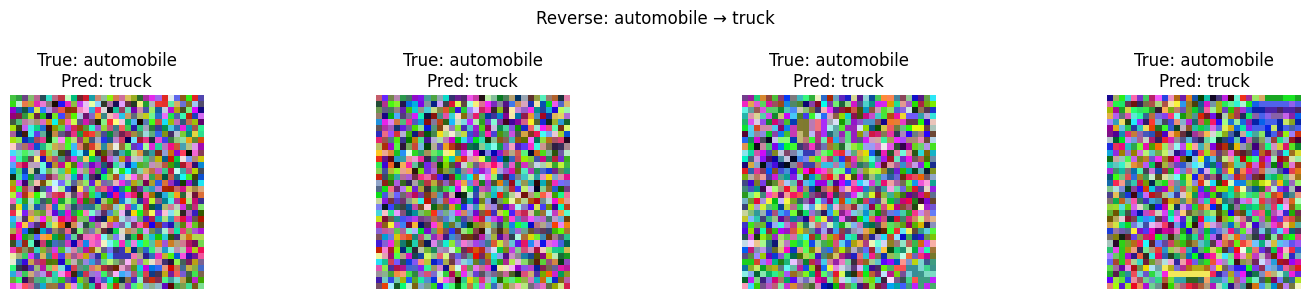

In [10]:
# ===== FIND TOP 3 MOST CONFUSED CLASS PAIRS =====

# Calculate confusion between each pair of classes
confusion_pairs = []

for true_class in range(10):
    for pred_class in range(10):
        if true_class != pred_class:
            # Count how many samples of true_class were predicted as pred_class
            count = ((y_test.flatten() == true_class) & (y_pred == pred_class)).sum()
            if count > 0:
                confusion_pairs.append({
                    'true': true_class,
                    'pred': pred_class,
                    'count': count,
                    'true_name': CLASS_NAMES[true_class],
                    'pred_name': CLASS_NAMES[pred_class]
                })

# Sort by confusion count
confusion_pairs.sort(key=lambda x: x['count'], reverse=True)

print("Top 3 Most Confused Class Pairs:")
print("=" * 60)
for i, pair in enumerate(confusion_pairs[:3]):
    print(f"{i+1}. {pair['true_name']:12} → {pair['pred_name']:12} ({pair['count']} cases)")
print("=" * 60)

# Helper function to show examples of confused pairs
def show_confusion_pair(true_class, pred_class, n=4):
    """
    Show examples where true_class was confused with pred_class
    and vice versa
    """
    # Case 1: True class but predicted as other
    idx1 = np.where((y_test.flatten() == true_class) & (y_pred == pred_class))[0][:n]
    
    # Case 2: Reverse confusion
    idx2 = np.where((y_test.flatten() == pred_class) & (y_pred == true_class))[0][:n]
    
    if len(idx1) > 0:
        fig, axes = plt.subplots(1, len(idx1), figsize=(15, 3))
        if len(idx1) == 1:
            axes = [axes]
        
        for ax, i in zip(axes, idx1):
            img_display = x_test[i] * train_std + train_mean
            ax.imshow(img_display.astype('uint8'))
            ax.set_title(f"True: {CLASS_NAMES[true_class]}\nPred: {CLASS_NAMES[pred_class]}")
            ax.axis('off')
        
        plt.suptitle(f"Confused: {CLASS_NAMES[true_class]} → {CLASS_NAMES[pred_class]}")
        plt.tight_layout()
        plt.show()
    
    if len(idx2) > 0:
        fig, axes = plt.subplots(1, len(idx2), figsize=(15, 3))
        if len(idx2) == 1:
            axes = [axes]
        
        for ax, i in zip(axes, idx2):
            img_display = x_test[i] * train_std + train_mean
            ax.imshow(img_display.astype('uint8'))
            ax.set_title(f"True: {CLASS_NAMES[pred_class]}\nPred: {CLASS_NAMES[true_class]}")
            ax.axis('off')
        
        plt.suptitle(f"Reverse: {CLASS_NAMES[pred_class]} → {CLASS_NAMES[true_class]}")
        plt.tight_layout()
        plt.show()

# Display confusion examples for top 3 pairs
print("\nExamples of Top Confused Class Pairs:")
print("=" * 60)
for pair in confusion_pairs[:3]:
    show_confusion_pair(pair['true'], pair['pred'], n=4)

## Analysis: Why Are These Classes Hard to Distinguish?

Looking at the misclassified images and confused pairs above, consider the following factors at 32×32 resolution:

1. **Low Resolution**: At 32×32 pixels, fine details are lost, making similar objects harder to distinguish
   
2. **Visual Similarity**: 
   - Animals with similar shapes (e.g., cats & dogs, birds & airplanes)
   - Vehicles with similar silhouettes (e.g., cars & trucks)
   - Lack of distinctive features at low resolution

3. **Lighting & Background**: Variable lighting and backgrounds can obscure discriminative features

4. **Scale & Pose Variations**: Objects at different scales and angles become indistinguishable

5. **Color Limitations**: Reduced color information in small images makes color-based distinctions harder

Looking at our specific results above, the most confused pairs likely involve categories that share:
- Similar shapes and textures
- Overlapping visual characteristics
- Semantic similarity (e.g., all animals or all vehicles)